# Sample-Specific Variance in Differential Analysis

This tutorial demonstrates how to account for biological variability between samples when performing differential analysis in single-cell data. We'll explore:

1. Why sample variance matters and how it impacts statistical significance
2. How to run Kompot analyses with and without sample variance correction
3. How to visualize and interpret the results from both approaches
4. The biological implications of accounting for sample-specific effects

## Introduction to Sample Variance

When analyzing single-cell data across multiple biological samples (e.g., different patients, mice, or experimental batches), accounting for sample-specific variability is crucial. The biological variation between samples is often larger than the variation between conditions, which can lead to inflated statistical significance and false positive results if not properly addressed.

Kompot provides built-in support for sample variance estimation that:

- Builds separate estimators for each sample to capture sample-specific patterns
- Computes variance across samples within each condition group
- Adjusts statistical significance based on the observed sample-to-sample variability
- Produces more conservative and biologically meaningful differential results

## Setup and Data Loading

Let's load the necessary libraries and set up our environment:

In [1]:
# TODO: REMOVE THIS
%load_ext autoreload
%autoreload 2

import os
import tempfile

os.environ["TMPDIR"] = "/loc/scratch/35159533"
tempfile.tempdir = None

In [2]:
import anndata as ad
import matplotlib.pyplot as plt

# Import necessary libraries
import numpy as np
import palantir
import pandas as pd
import scanpy as sc
import seaborn as sns

import kompot

# Set plotting style
plt.rcParams["axes.spines.right"] = False
plt.rcParams["axes.spines.top"] = False
plt.rcParams["image.cmap"] = "Spectral_r"

In this tutorial, we'll analyze a bone marrow dataset containing cells from young and old mice. We'll compare these two age groups while properly accounting for biological variation across individual samples within each age group.

In [3]:
# Data path - replace with your own AnnData file path
DATA_PATH = "../data/murine_bone_marrow_aging.h5ad"

# Analysis parameters
SAMPLE_COLUMN = "Replicate"  # Column in adata.obs with sample labels
GROUPING_COLUMN = "Age"  # Column in adata.obs with condition labels
CONDITIONS = ["Young", "Old"]  # Conditions to compare (first is reference)
CELL_TYPE_COLUMN = "highres_celltype"  # Column in adata.obs with cell type annotations
DIMENSIONALITY_REDUCTION = (
    "DM_EigenVectors"  # Key in adata.obsm for cell state representation
)
LAYER_FOR_EXPRESSION = (
    "logged_counts"  # Layer in adata.layers for expression data (None uses adata.X)
)

### Download dataset if not already present

This cell checks will download the paper dataset from https://zenodo.org/records/15587768 if not already presewnt.

In [4]:
import os
import requests
from tqdm.auto import tqdm

# Primary download URL (Zenodo)
URL = "https://zenodo.org/records/15587768/files/murine_bone_marrow_aging.h5ad?download=1"

os.makedirs(os.path.dirname(DATA_PATH), exist_ok=True)

if not os.path.exists(DATA_PATH):
    print(f"Downloading dataset from: {URL}")
    response = requests.get(URL, stream=True)
    total = int(response.headers.get("content-length", 0))
    with open(DATA_PATH, "wb") as file, tqdm(
        desc=os.path.basename(DATA_PATH),
        total=total,
        unit="B",
        unit_scale=True,
        unit_divisor=1024,
    ) as bar:
        for chunk in response.iter_content(chunk_size=8192):
            file.write(chunk)
            bar.update(len(chunk))
else:
    print(f"Dataset already available at {DATA_PATH}")

Dataset already available at ../data/murine_bone_marrow_aging.h5ad


In [5]:
adata = ad.read_h5ad(DATA_PATH)
adata

AnnData object with n_obs × n_vars = 8090 × 16285
    obs: 'Compartment', 'Replicate', 'Age', 'Sample', 'Info', 'batch', 'doublet_score', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'total_counts_hb', 'pct_counts_hb', 'S_score', 'G2M_score', 'phase', 'leiden', 'phenograph', 'highres_celltype', 'midres_celltype'
    var: 'gene_ids', 'feature_types', 'genome', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'hb', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'highly_variable_nbatches', 'highly_variable_intersection'
    uns: 'Age_colors', 'Compartment_colors', 'DMEigenValues', 'Info_colors', 'README', 'Replicate_colors', 'Sample_colors', 'batch_colors', 'draw_graph', 'highres_celltype_colors', 'hvg', 'leiden', 'leiden_colors', 'midres_celltype_colors', 'neighbors', 'pca', 'phase_colors', 'umap'
    obsm: 'AbCapture', 'DM_EigenVectors', 'HTO', 'X_draw_graph_fa', 'X_pca', 'X_pca_harmony', 'X_pca_noregression',

## Exploring the Data

Before performing differential analysis, it's important to understand the structure of your dataset. Let's visualize the data.

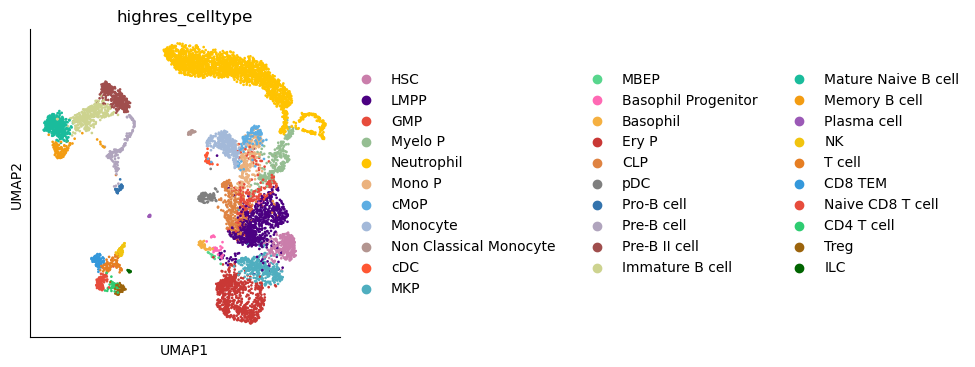

In [6]:
sc.pl.umap(adata, color=CELL_TYPE_COLUMN)

In [7]:
palantir.utils.run_diffusion_maps(adata, pca_key="X_pca_harmony", n_components=40);

## Standard Differential Analysis (Without Sample Variance)

First, we'll demonstrate the conventional differential analysis approach that doesn't account for sample-specific variability. This is the typical approach used when:
- There's only one sample per condition
- You're intentionally pooling all cells from each condition
- You want to establish a baseline for comparison with sample-variance-aware methods

### Step 1: Differential Abundance Analysis

We'll start by computing differential abundance between young and old conditions. This analyzes changes in cell state distribution between conditions:

In [8]:
# First, let's compute differential abundance between conditions
da_results = kompot.compute_differential_abundance(
    adata,  # AnnData object
    groupby=GROUPING_COLUMN,  # Column with condition labels
    condition1=CONDITIONS[0],  # Reference condition
    condition2=CONDITIONS[1],  # Comparison condition
    obsm_key=DIMENSIONALITY_REDUCTION,  # Cell state representation
)

[2025-10-03 10:10:50,135] [INFO    ] Condition 1 (Young): 2,917 cells
[2025-10-03 10:10:50,136] [INFO    ] Condition 2 (Old): 3,116 cells
[2025-10-03 10:10:50,140] [INFO    ] Fitting density estimator for condition 1...


[2025-10-03 10:11:20,198] [INFO    ] Fitting density estimator for condition 2...
[2025-10-03 10:11:33,599] [WARNING ] The normalization is only effective if the density was trained with d_method="fractal".
[2025-10-03 10:11:34,626] [WARNING ] The normalization is only effective if the density was trained with d_method="fractal".
[2025-10-03 10:11:40,892] [INFO    ] This run will have `run_id=0`.


### Step 2: Differential Expression Analysis

Next, we'll compute differential expression between the conditions using the same standard approach (without sample variance). This identifies genes that change in expression between young and old conditions:

In [9]:
# Now, compute differential expression between the conditions
de_results = kompot.compute_differential_expression(
    adata,  # AnnData object
    groupby=GROUPING_COLUMN,  # Column with condition labels
    condition1=CONDITIONS[0],  # Reference condition
    condition2=CONDITIONS[1],  # Comparison condition
    layer=LAYER_FOR_EXPRESSION,  # Expression data layer
    obsm_key=DIMENSIONALITY_REDUCTION,  # Cell state representation
    batch_size=0,  # set to, e.g., 100 to batch cells and genes for lower memory demand
)

[2025-10-03 10:11:42,348] [INFO    ] Condition 1 (Young): 2,917 cells
[2025-10-03 10:11:42,349] [INFO    ] Condition 2 (Old): 3,116 cells
[2025-10-03 10:11:42,349] [INFO    ] Using 8090 of 8090 cells (100.0%)
[2025-10-03 10:11:42,663] [INFO    ] Preparing null distribution with null_genes=2000, null_seed=42
[2025-10-03 10:11:43,904] [INFO    ] Generated shuffled expression for 2000 null genes
[2025-10-03 10:11:52,558] [INFO    ] Fitting expression estimator for condition 1...
[2025-10-03 10:12:02,002] [INFO    ] Fitting expression estimator for condition 2...
[2025-10-03 10:12:23,573] [INFO    ] Landmark storage skipped (store_landmarks=False). Compute with store_landmarks=True to enable landmark reuse.
[2025-10-03 10:12:57,842] [INFO    ] Using 5,000 landmarks for Mahalanobis computation
[2025-10-03 10:13:20,848] [INFO    ] Computing FDR statistics from null distribution
[2025-10-03 10:13:22,666] [INFO    ] FDR analysis complete: 393/16285 genes significantly DE at FDR < 0.05
[2025-10

## Differential Analysis With Sample Variance

Now, we'll perform the same analyses while properly accounting for sample-specific variability. The key difference is the addition of the `sample_col` parameter, which tells Kompot which column in `adata.obs` contains the sample identifiers.

### Step 1: Differential Abundance with Sample Variance

First, we'll compute differential abundance while accounting for sample variability. Since we are accounting for more variability, it is often beneficial to relax the threshold. E.g., here we increase the posterior tail probability from the default 0.05 to 0.1.

In [10]:
# First, let's compute differential abundance between conditions
da_results = kompot.compute_differential_abundance(
    adata,  # AnnData object
    groupby=GROUPING_COLUMN,  # Column with condition labels
    condition1=CONDITIONS[0],  # Reference condition
    condition2=CONDITIONS[1],  # Comparison condition
    obsm_key=DIMENSIONALITY_REDUCTION,  # Cell state representation
    sample_col=SAMPLE_COLUMN,  # Sample labels
    ptp_threshold=0.1 # relaxed threshold
)

[2025-10-03 10:13:33,930] [INFO    ] Results with result_key='kompot_da' already exist in the dataset. Previous run was at 2025-10-03T10:11:40.892212 comparing Young to Old. Fields that will be overwritten: obs.kompot_da_Young_to_Old_lfc, obs.kompot_da_Young_log_density, obs.kompot_da_Old_log_density. Note: Only fields NOT affected by sample variance (like lfc, log_density) will be overwritten since they don't use the sample variance suffix. These results will likely be identical if other parameters haven't changed. This is a partial rerun with sample variance added to a previous analysis with matching parameters. Set overwrite=False to prevent overwriting or overwrite=True to silence this message.
[2025-10-03 10:13:33,933] [INFO    ] Condition 1 (Young): 2,917 cells
[2025-10-03 10:13:33,934] [INFO    ] Condition 2 (Old): 3,116 cells
[2025-10-03 10:13:33,939] [INFO    ] Using sample column 'Replicate' for sample variance estimation
[2025-10-03 10:13:33,941] [INFO    ] Found 3 unique sa

### Step 2: Differential Expression with Sample Variance

When incorporating sample variance in differential expression analysis, memory usage can increase significantly because Kompot computes a gene-specific covariance matrix for each gene. To manage memory efficiently, we'll analyze only the top 200 genes (by Mahalanobis distance) from our previous analysis. We'll also enable disk storage for large matrices. Note that we are disableing the computation of a null distribution and therefore any false discovery rates with `null_genes=0` to avoid computing costly gene-specific covariance matrix for null genes. To avoid using too much memory, the `store_arrays_on_disk=True` flag will enabled disk backed computation for the covariance tensor.

The `dry_run_differential_expression` utility takes the same argumenyts as the `compute_differential_expression` function and lays out upcoming resource usage. This helps to anticipate and plan resource usage. Note that nathing is stored permamently and data not written to the anndata is removed after completing the computation.

In [11]:
# Now, compute differential expression between the conditions
topn = 200 # use a subset of genes to reduce resource demand
genes = adata.var.sort_values("kompot_de_Young_to_Old_mahalanobis", ascending=False).head(topn).index
plan = kompot.dry_run_differential_expression(
    adata,  # AnnData object
    groupby=GROUPING_COLUMN,  # Column with condition labels
    condition1=CONDITIONS[0],  # Reference condition
    condition2=CONDITIONS[1],  # Comparison condition
    layer=LAYER_FOR_EXPRESSION,  # Expression data layer
    obsm_key=DIMENSIONALITY_REDUCTION,  # Cell state representation
    batch_size=0,  # set to, e.g., 100 to batch-process cells for lower memory demand
    store_arrays_on_disk=True, # stores covariance matrices on disk to process larger amounts of genes at once
    sample_col=SAMPLE_COLUMN,  # Sample labels
    genes=genes, # genes to be processed
    n_landmarks=200,
    null_genes=0, # disable costly fdr computation
)

RESOURCE USAGE PLAN

System Resources:
  Memory: 427.67 GB available (of 754.59 GB total)
  Disk:   6.04 TB available at /loc/scratch/35159533

Total Requirements:
  Memory: 203.46 MB (0% of available)
  Disk:   122.07 MB (0% of available)

Memory Allocations:
  • Mellon precision matrix L (condition 1, 2,917/3,116 cells) (2917, 2917): 64.92 MB
  • Mellon precision matrix L (condition 2, 2,917/3,116 cells) (3116, 3116): 74.08 MB
  • Imputed expression (condition 1) (8090, 200): 12.34 MB → adata.layers['kompot_de_Young_imputed']
  • Imputed expression (condition 2) (8090, 200): 12.34 MB → adata.layers['kompot_de_Old_imputed']
  • Fold change (8090, 200): 12.34 MB → adata.layers['kompot_de_Young_to_Old_fold_change']
  • Standard deviation (condition 1) (8090, 200): 12.34 MB → adata.layers['kompot_de_Young_std']
  • Standard deviation (condition 2) (8090, 200): 12.34 MB → adata.layers['kompot_de_Old_std']
  • Function predictor covariances (per condition) (200, 200): 625.00 KB
  • Combine

We have enough resources on this machin and the overwrites are anticipated since we repeat the same comparison we previously did without sample variance and the only results overwritten are not effected by sample variance.

In [12]:
de_results = kompot.compute_differential_expression(
    adata,  # AnnData object
    groupby=GROUPING_COLUMN,  # Column with condition labels
    condition1=CONDITIONS[0],  # Reference condition
    condition2=CONDITIONS[1],  # Comparison condition
    layer=LAYER_FOR_EXPRESSION,  # Expression data layer
    obsm_key=DIMENSIONALITY_REDUCTION,  # Cell state representation
    batch_size=0,  # set to, e.g., 100 to batch-process cells for lower memory demand
    store_arrays_on_disk=True, # stores covariance matrices on disk to process larger amounts of genes at once
    sample_col=SAMPLE_COLUMN,  # Sample labels
    genes=genes, # genes to be processed
    null_genes=0, # disable costly fdr computation
)

[2025-10-03 10:14:54,763] [INFO    ] Differential expression results with result_key='kompot_de' already exist in the dataset. Previous run was at 2025-10-03T10:13:27.714008 comparing Young to Old. Fields that will be overwritten: var.kompot_de_Young_to_Old_mean_lfc, layers.kompot_de_Young_imputed, layers.kompot_de_Old_imputed, layers.kompot_de_Young_to_Old_fold_change. Note: Only fields NOT affected by sample variance (like mean_log_fold_change, imputed data, fold_change) will be overwritten since they don't use the sample variance suffix. These results will likely be identical if other parameters haven't changed. This is a partial rerun with sample variance added to a previous analysis with matching parameters. Set overwrite=False to prevent overwriting or overwrite=True to silence this message.
[2025-10-03 10:14:54,766] [INFO    ] Condition 1 (Young): 2,917 cells
[2025-10-03 10:14:54,767] [INFO    ] Condition 2 (Old): 3,116 cells
[2025-10-03 10:14:54,768] [INFO    ] Using 8090 of 80

Processing gene-specific covariance matrices:   0%|          | 0/200 [00:00<?, ?it/s]

[2025-10-03 10:20:03,798] [INFO    ] Computing Mahalanobis distances using gene-specific covariance matrices
[2025-10-03 10:20:03,799] [INFO    ] Computing Mahalanobis distances for 200 genes using dask


Computing Mahalanobis distances:   0%|          | 0/200 [00:00<?, ?it/s]

[2025-10-03 10:24:46,369] [INFO    ] Successfully computed Mahalanobis distances for 200 genes using gene-specific covariance
[2025-10-03 10:25:18,545] [INFO    ] This run will have `run_id=1`.
[2025-10-03 10:25:18,605] [INFO    ] Removed temporary storage directory /loc/scratch/35159533/kompot_arrays_2ddf3df6_o_6fc_1c
[2025-10-03 10:25:18,678] [INFO    ] Removed temporary storage directory /loc/scratch/35159533/kompot_arrays_8c3d3671_ssjgrxst


## Comparing Results: With vs. Without Sample Variance

Now let's compare the results from both approaches to understand how accounting for sample variance affects our differential analysis outcomes.

### Comparing Differential Abundance Results

First, we'll visualize the differential abundance results on the UMAP embedding. We'll compare:
1. The direction of abundance changes (increasing or decreasing)
2. The magnitude of log fold changes in abundance
3. The statistical significance (z-scores) with and without sample variance correction

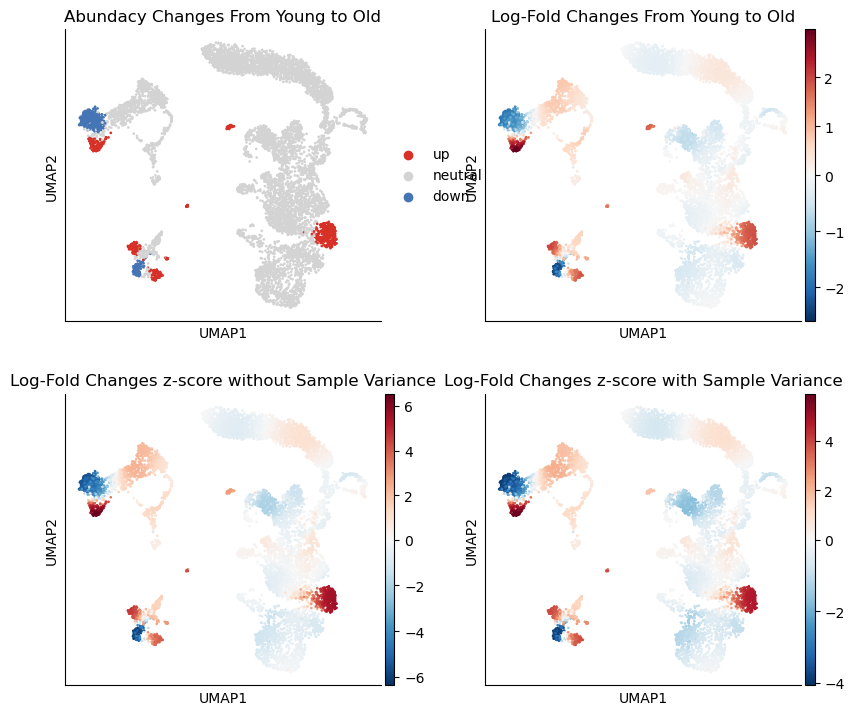

In [13]:
sc.pl.embedding(
    adata,
    "umap",
    color=[
        "kompot_da_Young_to_Old_lfc_direction",
        "kompot_da_Young_to_Old_lfc",
        "kompot_da_Young_to_Old_lfc_zscore",
        "kompot_da_Young_to_Old_lfc_zscore_sample_var",
    ],
    title=[
        "Abundacy Changes From Young to Old",
        "Log-Fold Changes From Young to Old",
        "Log-Fold Changes z-score without Sample Variance",
        "Log-Fold Changes z-score with Sample Variance",
    ],
    color_map="RdBu_r",
    vcenter=0,
    ncols=2,
)

### Volcano Plots for Differential Abundance

Volcano plots provide an effective way to visualize differential abundance results. They display the log fold change (effect size) on the x-axis and statistical significance on the y-axis. Points above the horizontal line and outside the vertical lines represent statistically significant changes.

Let's first examine the standard analysis without sample variance correction. To specify which data the plotting function should use, we can either provide the `lfc_key` and `ptp_key` columns with results created by the `compute_differential_abundance` function, or provide the `run_id` that identifies the differential abundance run (the first run has `run_id=0`):

[2025-10-03 10:25:20,359] [INFO    ] Found DA run info for run_id=0
[2025-10-03 10:25:20,360] [INFO    ] Found lfc_key='kompot_da_Young_to_Old_lfc' from run info
[2025-10-03 10:25:20,361] [INFO    ] Found ptp_key='kompot_da_Young_to_Old_neg_log10_lfc_ptp' from run info
[2025-10-03 10:25:20,361] [WARNING ] Field 'kompot_da_Young_to_Old_lfc' has been written by 2 different runs, indicating potential overwrites
[2025-10-03 10:25:20,362] [WARNING ] Field 'kompot_da_Young_to_Old_neg_log10_lfc_ptp' was last written by run 0, but current context expects run 1. The field may have been overwritten.
[2025-10-03 10:25:20,363] [INFO    ] Successfully inferred fields: {'lfc_key': 'kompot_da_Young_to_Old_lfc', 'ptp_key': 'kompot_da_Young_to_Old_neg_log10_lfc_ptp'}
[2025-10-03 10:25:20,363] [WARNING ] Field inference completed with 2 warnings
[2025-10-03 10:25:20,364] [INFO    ] Using inferred thresholds - lfc_threshold: 1.0, ptp_threshold: 0.05


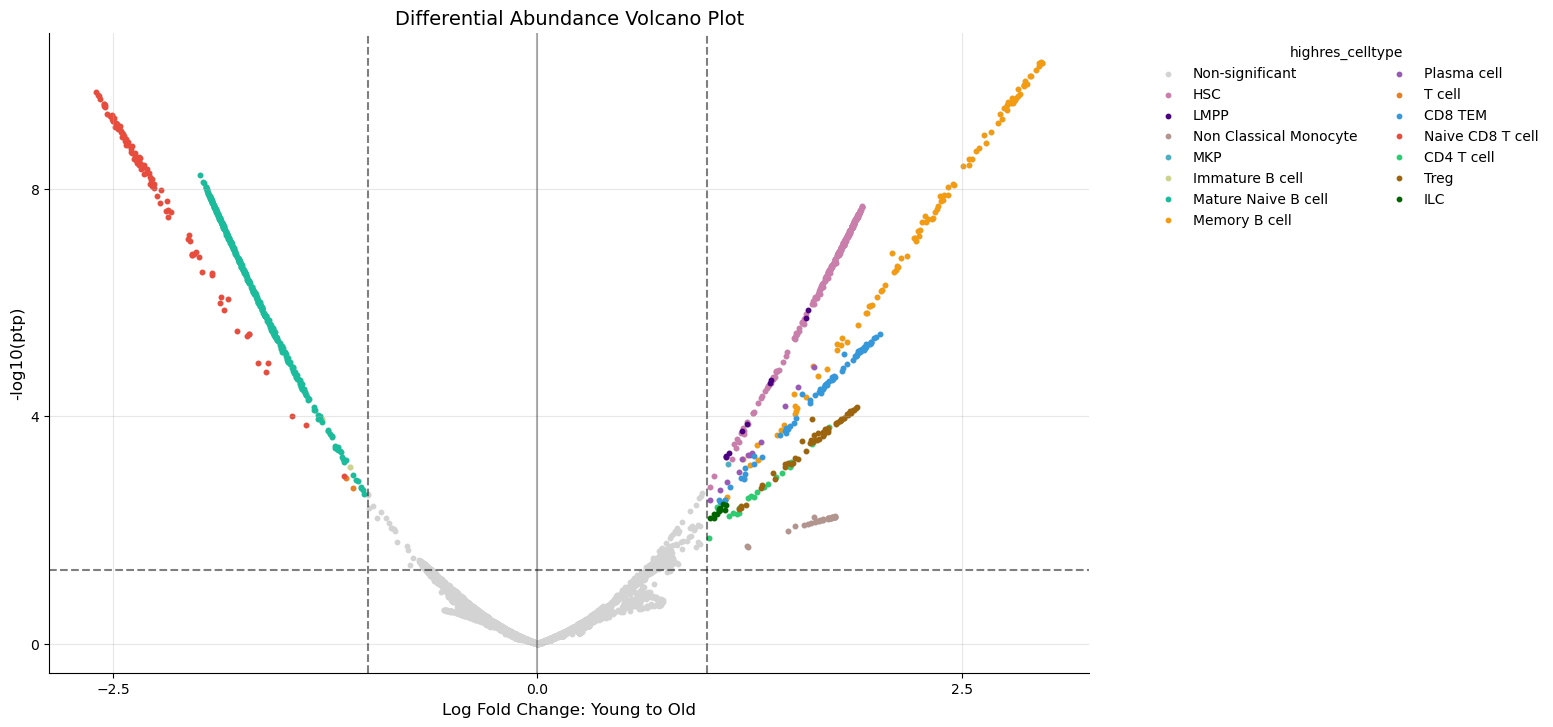

In [14]:
kompot.plot.volcano_da(adata, color=CELL_TYPE_COLUMN, run_id=0)

Now, let's examine the analysis with sample variance correction (`run_id=1`):

[2025-10-03 10:25:20,841] [INFO    ] Found DA run info for run_id=1
[2025-10-03 10:25:20,842] [INFO    ] Found lfc_key='kompot_da_Young_to_Old_lfc' from run info
[2025-10-03 10:25:20,842] [INFO    ] Found ptp_key='kompot_da_Young_to_Old_neg_log10_lfc_ptp_sample_var' from run info
[2025-10-03 10:25:20,843] [WARNING ] Field 'kompot_da_Young_to_Old_lfc' has been written by 2 different runs, indicating potential overwrites
[2025-10-03 10:25:20,844] [INFO    ] Successfully inferred fields: {'lfc_key': 'kompot_da_Young_to_Old_lfc', 'ptp_key': 'kompot_da_Young_to_Old_neg_log10_lfc_ptp_sample_var'}
[2025-10-03 10:25:20,844] [WARNING ] Field inference completed with 1 warnings
[2025-10-03 10:25:20,845] [INFO    ] Using inferred thresholds - lfc_threshold: 1.0, ptp_threshold: 0.05


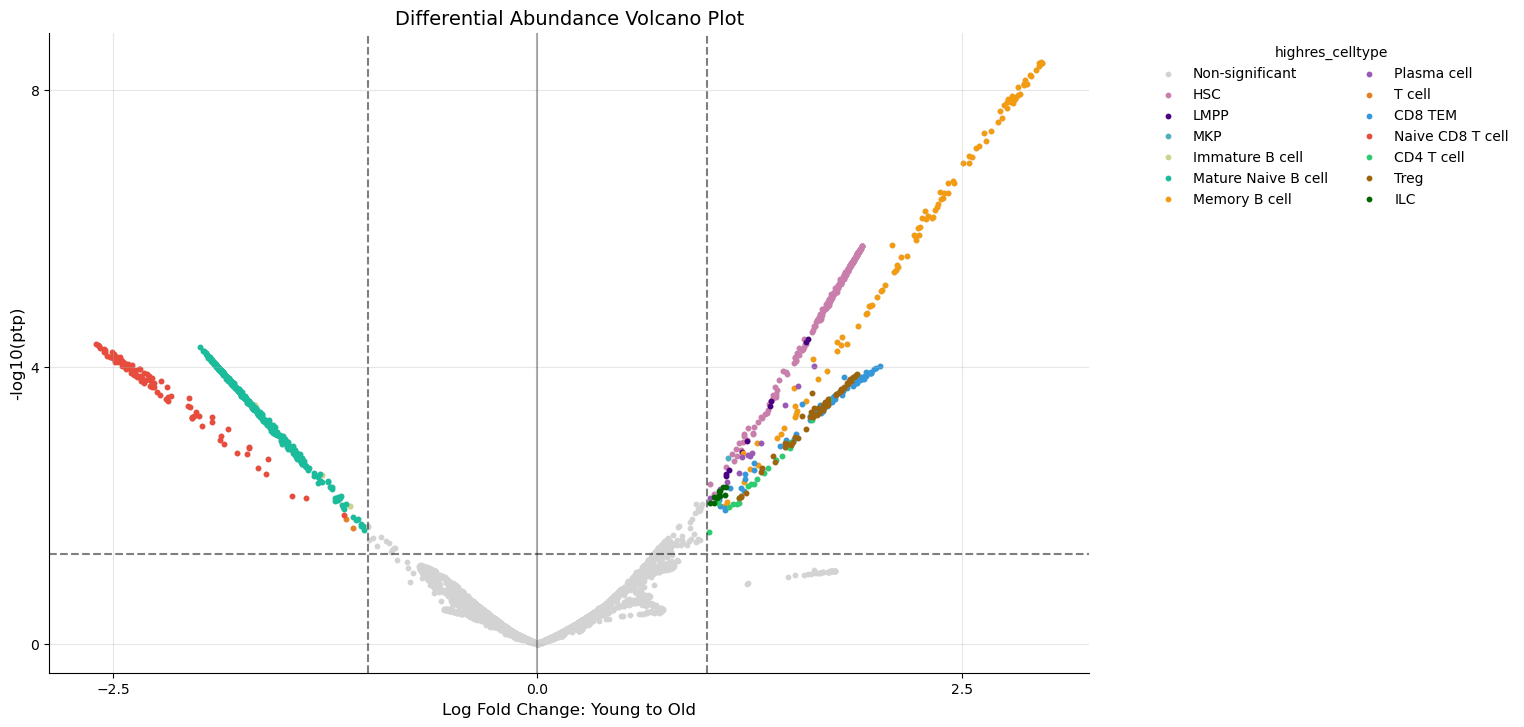

In [15]:
kompot.plot.volcano_da(adata, color=CELL_TYPE_COLUMN, run_id=1)

Note that thresholds such as `ptp_threshold` and `lfc_threshold` can be adjusted an if `update_direction=True` is passed, than the cell-wise classification in `adata.obs["kompot_da_Young_to_Old_lfc_direction_sample_var"]` is updated accordingly.

[2025-10-03 11:20:01,657] [INFO    ] Found DA run info for run_id=1
[2025-10-03 11:20:01,658] [INFO    ] Found lfc_key='kompot_da_Young_to_Old_lfc' from run info
[2025-10-03 11:20:01,659] [INFO    ] Found ptp_key='kompot_da_Young_to_Old_neg_log10_lfc_ptp_sample_var' from run info
[2025-10-03 11:20:01,660] [WARNING ] Field 'kompot_da_Young_to_Old_lfc' has been written by 2 different runs, indicating potential overwrites
[2025-10-03 11:20:01,661] [INFO    ] Successfully inferred fields: {'lfc_key': 'kompot_da_Young_to_Old_lfc', 'ptp_key': 'kompot_da_Young_to_Old_neg_log10_lfc_ptp_sample_var'}
[2025-10-03 11:20:01,662] [WARNING ] Field inference completed with 1 warnings
[2025-10-03 11:20:01,662] [INFO    ] Using inferred thresholds - lfc_threshold: 1.0, ptp_threshold: 0.2


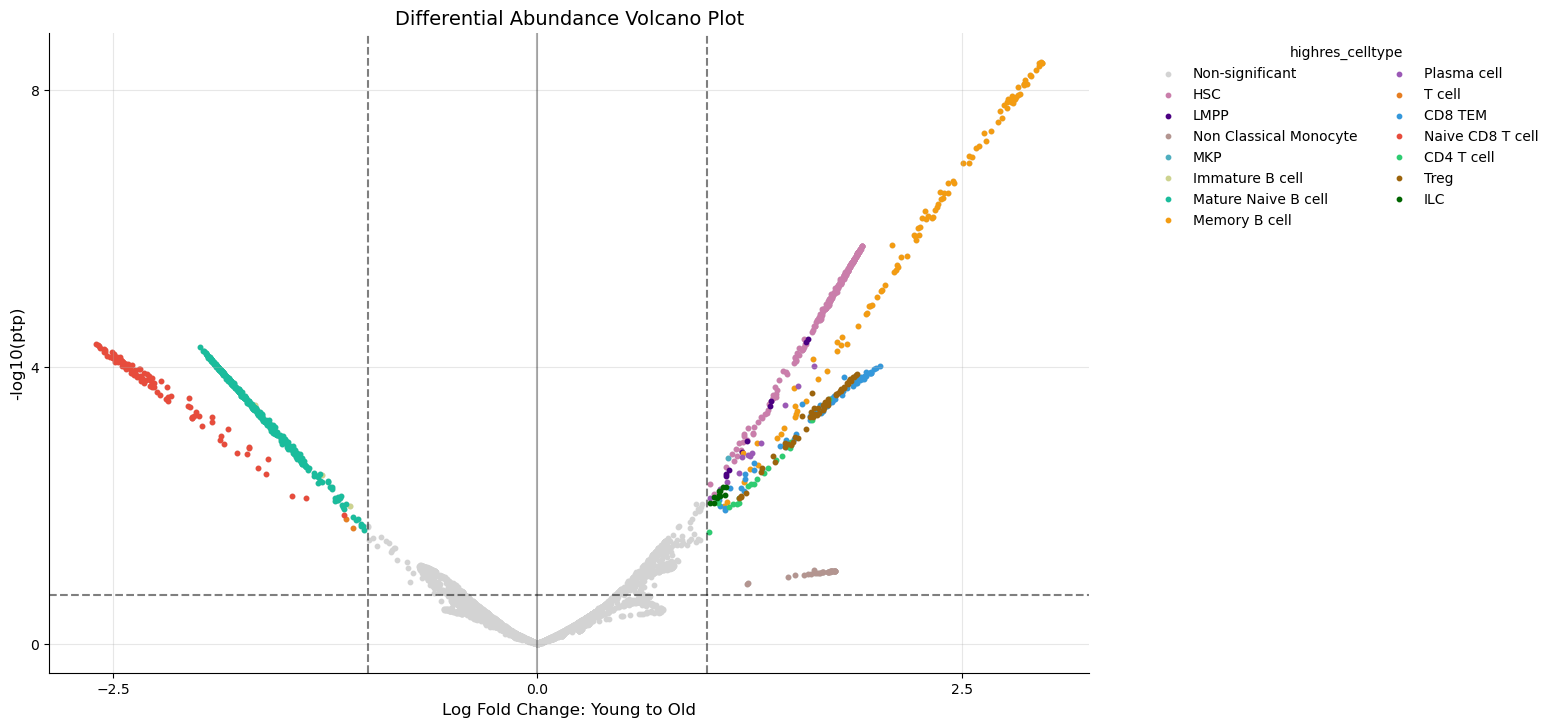

In [24]:
kompot.plot.volcano_da(adata, color=CELL_TYPE_COLUMN, run_id=1, ptp_threshold=0.2, update_direction=True)

### Key Observations from Differential Abundance Analysis

Comparing the volcano plots with and without sample variance correction reveals several important differences:

1. **Reduced statistical significance**: Posterior Tail Probabilities (y-axis) are generally lower when using sample variance correction, reflecting a more conservative statistical assessment that accounts for biological variability.

2. **Consistent cell type patterns**: Both plots show similar cell type-specific patterns of differential abundance, but with different significance thresholds.

3. **Unchanged effect sizes**: The log fold changes (x-axis) remain identical between methods, as sample variance affects statistical significance but not the estimation of effect size.

## Comparing Differential Expression Results

Now let's examine how sample variance correction affects differential gene expression analysis.

### Top Differentially Expressed Genes

First, let's examine the top differentially expressed genes identified in our standard analysis (without sample variance correction):

In [16]:
adata.var.loc[:, adata.var.columns.str.contains("kompot_de")].sort_values("kompot_de_Young_to_Old_mahalanobis", ascending=False).head(20)

,kompot_de_Young_to_Old_mahalanobis,kompot_de_Young_to_Old_mean_lfc,kompot_de_Young_to_Old_mahalanobis_local_fdr,kompot_de_Young_to_Old_is_de,kompot_de_Young_to_Old_mahalanobis_sample_var
H2-Q7,71.517323,1.235066,0.014892,True,45.085446
Cd74,60.021452,0.352121,0.014892,True,49.584290
H2-Aa,59.371135,0.473756,0.014892,True,38.489260
H2-Ab1,57.808982,0.511123,0.014892,True,33.768536
Igkc,53.604112,0.054009,0.014892,True,38.973926
H2-Eb1,53.403829,0.411752,0.014892,True,31.734637
AW112010,53.386235,0.791367,0.014892,True,28.091721
S100a9,48.765184,-0.170317,0.014892,True,46.502283
Ifitm3,47.585813,0.367545,0.014892,True,40.375510
S100a8,47.372815,-0.165121,0.014892,True,45.495007


### Volcano Plots for Differential Expression

Now, let's visualize differential expression results using volcano plots. First, we'll look at the standard analysis without sample variance correction (`run_id=0`):

[2025-10-03 10:25:21,345] [INFO    ] Found DE run info for run_id=0
[2025-10-03 10:25:21,346] [INFO    ] Found mean_lfc_key='kompot_de_Young_to_Old_mean_lfc' from run info
[2025-10-03 10:25:21,347] [INFO    ] Found mahalanobis_key='kompot_de_Young_to_Old_mahalanobis' from run info
[2025-10-03 10:25:21,348] [WARNING ] Field 'kompot_de_Young_to_Old_mean_lfc' has been written by 2 different runs, indicating potential overwrites
[2025-10-03 10:25:21,350] [WARNING ] Field 'kompot_de_Young_to_Old_mahalanobis' was last written by run 0, but current context expects run 1. The field may have been overwritten.
[2025-10-03 10:25:21,351] [INFO    ] Successfully inferred fields: {'mean_lfc_key': 'kompot_de_Young_to_Old_mean_lfc', 'mahalanobis_key': 'kompot_de_Young_to_Old_mahalanobis'}
[2025-10-03 10:25:21,352] [WARNING ] Field inference completed with 2 warnings
[2025-10-03 10:25:21,353] [INFO    ] Using DE run 0: comparing Young to Old
[2025-10-03 10:25:21,366] [INFO    ] Using data columns from 

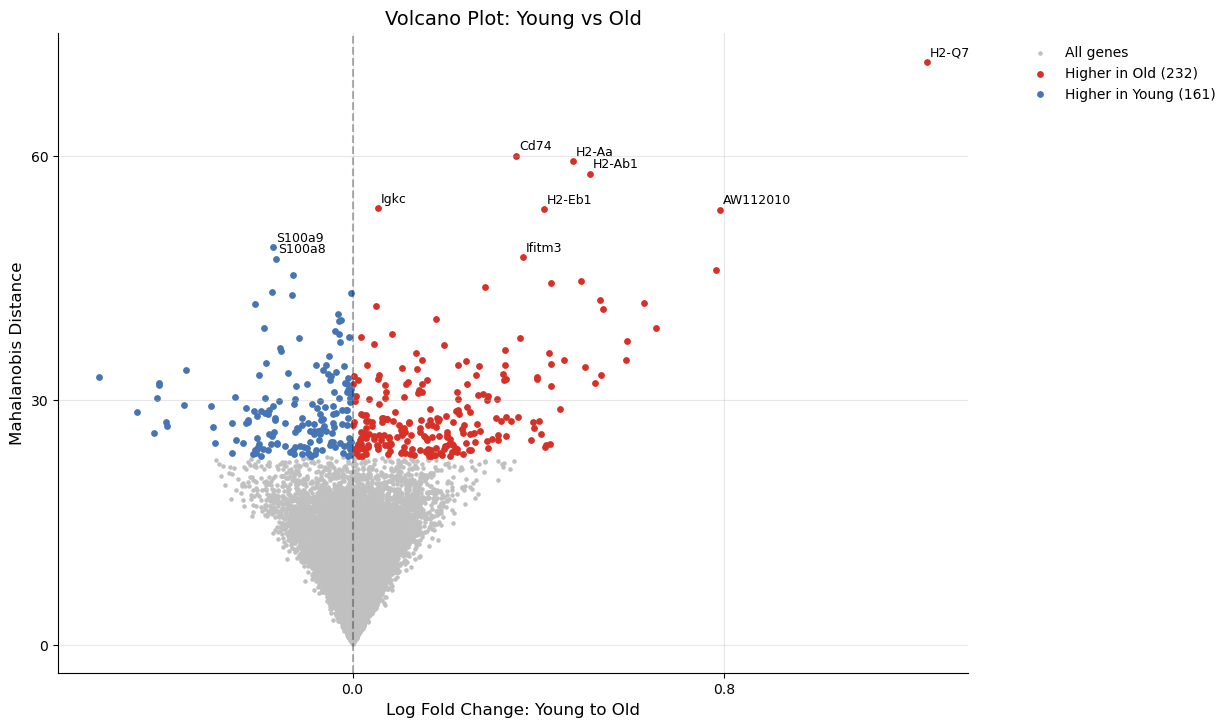

In [17]:
kompot.plot.volcano_de(
    adata,
    run_id=0,
)

Next, let's look at the analysis with sample variance correction (`run_id=1`). Notice how some genes show markedly lower significance (Mahalanobis distance) when accounting for sample-to-sample variability. Note that since the nulldistribution was not computed above, we do not have a fase discivery rate to select a threshold here.

[2025-10-03 10:31:31,857] [INFO    ] Found DE run info for run_id=1
[2025-10-03 10:31:31,858] [INFO    ] Found mean_lfc_key='kompot_de_Young_to_Old_mean_lfc' from run info
[2025-10-03 10:31:31,859] [INFO    ] Found mahalanobis_key='kompot_de_Young_to_Old_mahalanobis_sample_var' from run info
[2025-10-03 10:31:31,860] [WARNING ] Field 'kompot_de_Young_to_Old_mean_lfc' has been written by 2 different runs, indicating potential overwrites
[2025-10-03 10:31:31,861] [INFO    ] Successfully inferred fields: {'mean_lfc_key': 'kompot_de_Young_to_Old_mean_lfc', 'mahalanobis_key': 'kompot_de_Young_to_Old_mahalanobis_sample_var'}
[2025-10-03 10:31:31,862] [WARNING ] Field inference completed with 1 warnings
[2025-10-03 10:31:31,863] [INFO    ] Using DE run 1: comparing Young to Old
[2025-10-03 10:31:31,874] [INFO    ] Using data columns from var - lfc: 'kompot_de_Young_to_Old_mean_lfc', score: 'kompot_de_Young_to_Old_mahalanobis_sample_var'
[2025-10-03 10:31:31,877] [INFO    ] Highlighting top 10

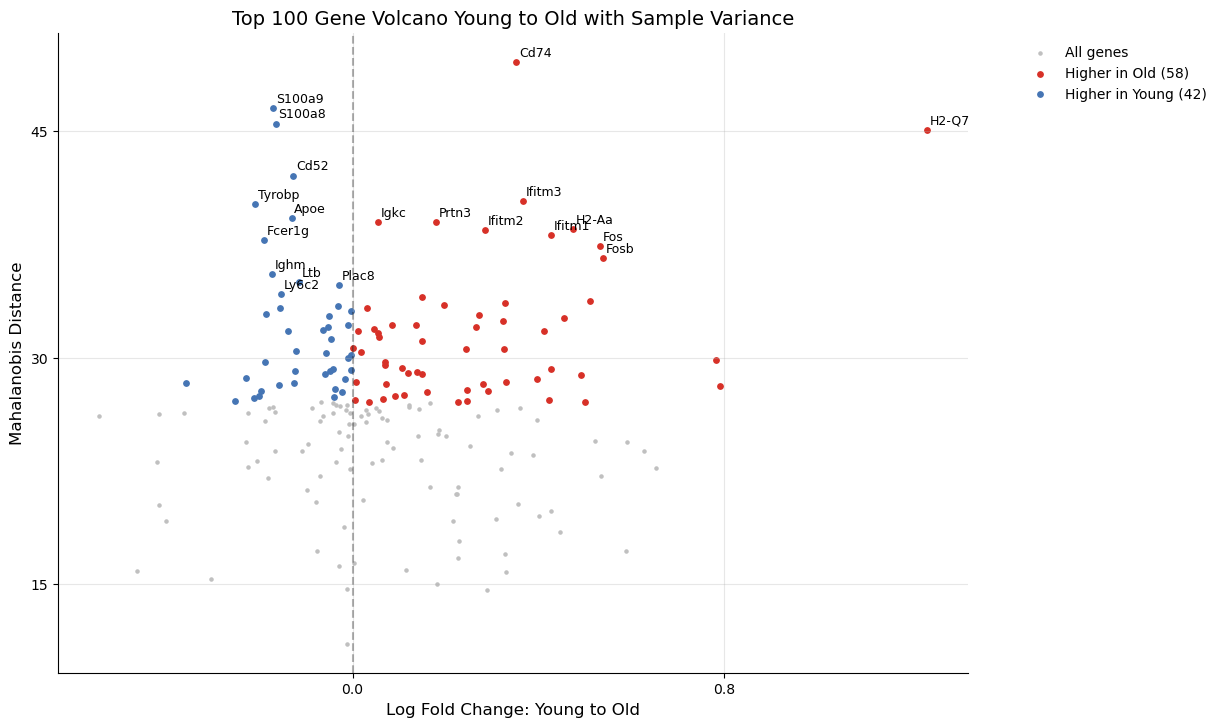

In [23]:
kompot.plot.volcano_de(
    adata,
    n_top_genes=100, # highlight only the top 100 genes instead of picking a significance threshold
    gene_labels=20, # label more genes
    run_id=1,
    title="Top 100 Gene Volcano Young to Old with Sample Variance",
)

### Heatmaps of Top Differentially Expressed Genes

Heatmaps provide a cell type-specific view of expression changes. The expression values shown are averages of the actual expression values per cell type group, while the gene ranking is determined by the Mahalanobis distance computed by Kompot.

Let's first create a heatmap for the top genes identified without sample variance correction (`run_id=0`):

[2025-10-03 10:25:21,927] [INFO    ] Found DE run info for run_id=0
[2025-10-03 10:25:21,928] [INFO    ] Found mahalanobis_key='kompot_de_Young_to_Old_mahalanobis' from run info
[2025-10-03 10:25:21,929] [WARNING ] Field 'kompot_de_Young_to_Old_mahalanobis' was last written by run 0, but current context expects run 1. The field may have been overwritten.
[2025-10-03 10:25:21,929] [INFO    ] Successfully inferred fields: {'mahalanobis_key': 'kompot_de_Young_to_Old_mahalanobis'}
[2025-10-03 10:25:21,930] [WARNING ] Field inference completed with 1 warnings
[2025-10-03 10:25:21,931] [INFO    ] Using DE run 0 for heatmap.
[2025-10-03 10:25:21,931] [INFO    ] Inferred score_key='kompot_de_Young_to_Old_mahalanobis' from run information
[2025-10-03 10:25:21,935] [INFO    ] Inferred condition_column='Age' from run information
[2025-10-03 10:25:21,936] [INFO    ] Inferred condition1='Young' from run information
[2025-10-03 10:25:21,936] [INFO    ] Inferred condition2='Old' from run information


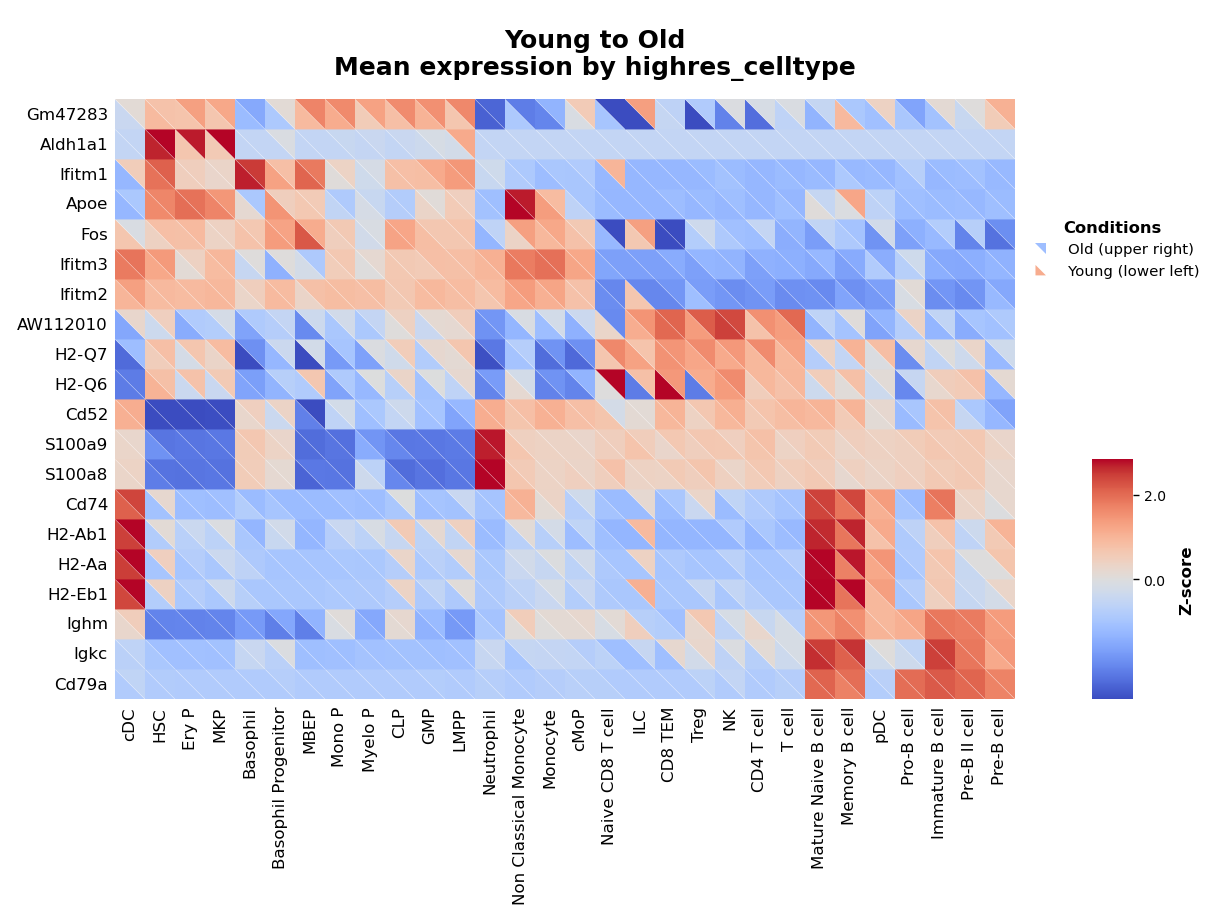

In [19]:
kompot.plot.heatmap(
    adata,
    n_top_genes=20,
    groupby=CELL_TYPE_COLUMN,
    exclude_groups="Plasma cell",
    run_id=0,
    vmin="p1",
    vmax="p99",
)

Now, showing the top 20 genes when ranking them considering sample variance (`run_id=1`):

To understand why sample variance matters, let's examine genes that show high variability between samples. The following heatmap displays genes with the lowest significance scores after sample variance correction, comparing expression between replicate 1 and replicate 3:

[2025-10-03 10:25:23,410] [INFO    ] Inferred layer='logged_counts' from run information
[2025-10-03 10:25:23,411] [INFO    ] Creating split heatmap with 20 genes/features
[2025-10-03 10:25:23,412] [INFO    ] Using display names: 'Replicate 1' for condition1, 'Replicate 3' for condition2
[2025-10-03 10:25:23,413] [INFO    ] Using expression data from layer: 'logged_counts'
[2025-10-03 10:25:23,484] [INFO    ] Applying gene-wise z-scoring (standard_scale='var')


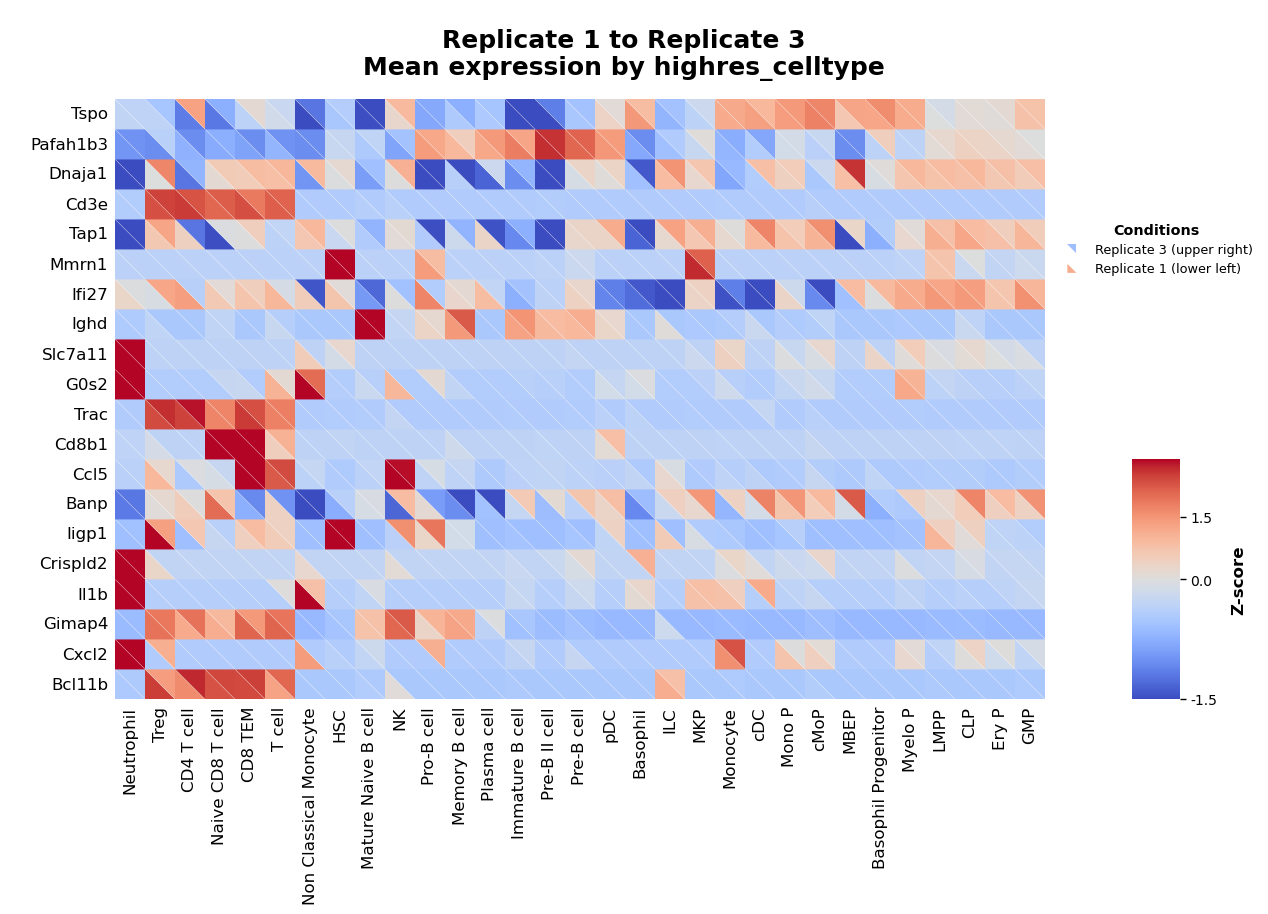

In [20]:
kompot.plot.heatmap(
    adata,
    genes=adata.var.sort_values(
        "kompot_de_Young_to_Old_mahalanobis_sample_var", ascending=False, na_position='first'
    ).tail(20).index,
    groupby=CELL_TYPE_COLUMN,
    condition_column=SAMPLE_COLUMN,
    condition1="1",
    condition1_name="Replicate 1",
    condition2="3",
    condition2_name="Replicate 3",
    vmin="p2",
    vmax="p98",
    cluster_rows=False,
)

### Detailed Expression Visualization

For specific genes of interest, we can create detailed visualizations that show:
1. Original expression in the dataset
2. Imputed expression in each condition (young and old)
3. Log fold change between conditions

Since these visualizations are not affected by sample variance correction, we can let the plotting function use the latest results from either analysis.

Let's look at a T-cell marker gene (Cd3g):

[2025-10-03 10:25:25,518] [INFO    ] Found DE run info for run_id=-1
[2025-10-03 10:25:25,519] [INFO    ] Found mean_lfc_key='kompot_de_Young_to_Old_mean_lfc' from run info
[2025-10-03 10:25:25,520] [INFO    ] Found mahalanobis_key='kompot_de_Young_to_Old_mahalanobis_sample_var' from run info
[2025-10-03 10:25:25,521] [WARNING ] Field 'kompot_de_Young_to_Old_mean_lfc' has been written by 2 different runs, indicating potential overwrites
[2025-10-03 10:25:25,522] [INFO    ] Successfully inferred fields: {'mean_lfc_key': 'kompot_de_Young_to_Old_mean_lfc', 'mahalanobis_key': 'kompot_de_Young_to_Old_mahalanobis_sample_var'}
[2025-10-03 10:25:25,522] [WARNING ] Field inference completed with 1 warnings
[2025-10-03 10:25:25,523] [INFO    ] Using DE run 1: comparing Young to Old
[2025-10-03 10:25:25,524] [INFO    ] Using fields for gene expression plot - lfc_key: 'kompot_de_Young_to_Old_mean_lfc', score_key: 'kompot_de_Young_to_Old_mahalanobis_sample_var'
[2025-10-03 10:25:25,524] [INFO    ] 

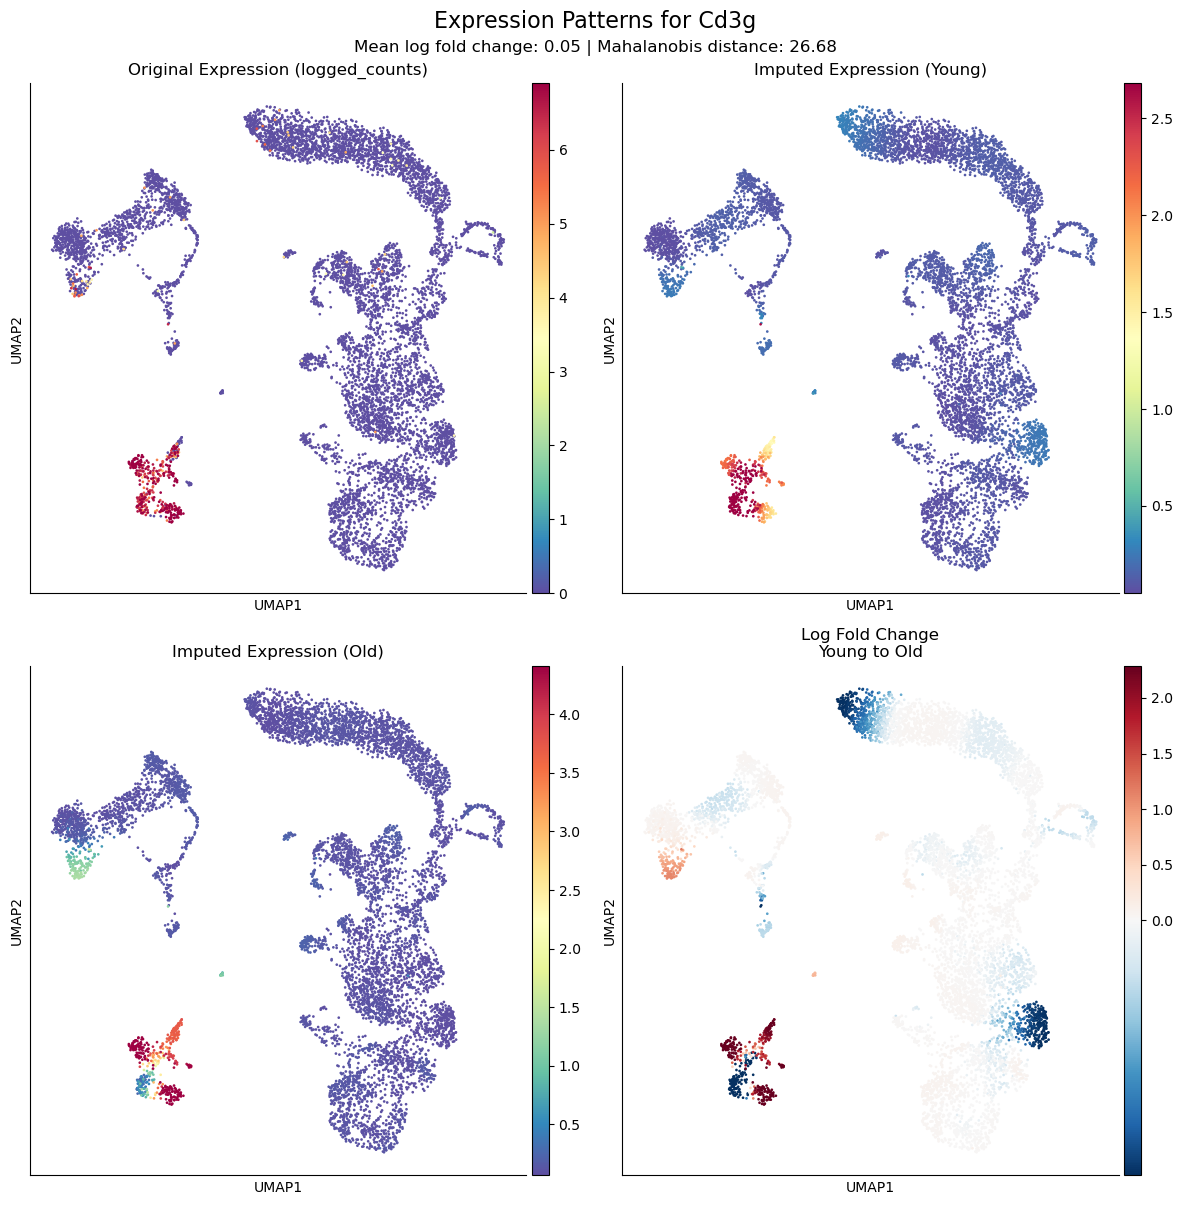

In [21]:
kompot.plot.plot_gene_expression(adata, gene="Cd3g", vmin="p2", vmax="p98")

### Inspecting Run Parameters and Results Tracking

Kompot tracks all parameters and AnnData manipulations for each analysis run. This information can be inspected and compared between runs using the [RunInfo](https://kompot.readthedocs.io/en/latest/anndata.html#kompot.anndata.utils.RunInfo) utility and its `.compare_to()` method.

Let's examine the first differential expression run (`run_id=0`) without sample variance:

> **Note**: Some results have been overwritten by the sample variance-aware run (`run_id=1`). However, results that are not affected by sample variance (like log fold changes) remain identical between runs since all other parameters were the same. Results affected by sample variance are saved with a `_sample_var` suffix (e.g., `kompot_de_mahalanobis_Young_to_Old_sample_var`) to avoid naming conflicts.

In [22]:
kompot.RunInfo(adata, run_id=0, analysis_type="de")

Parameter,Value
conditions,Young to Old
obsm_key,DM_EigenVectors
uses_sample_variance,False
layer,logged_counts
timestamp,2025-10-03T10:13:27.714008
Fields Created,9
Parameter,Value
auto_filtered,False
batch_size,0
compute_mahalanobis,True


## Conclusion: The Impact of Sample Variance Correction

After comparing analyses with and without sample variance correction, several key insights emerge:

1. **Reduced false positives**: Sample variance correction significantly reduces the number of statistically significant findings, particularly for genes and cell states with high variability between samples.

2. **More robust biomarkers**: Genes that remain significant after sample variance correction are more likely to represent robust biological differences between conditions rather than sample-specific effects or technical artifacts.

3. **Preserved effect sizes**: The log fold changes themselves remain identical with both methods; only the statistical significance (Posterior Tail Probabilities/Mahalanobis distances) changes when accounting for sample variability.

4. **Cell type-specific reliability**: Some cell types show more consistent changes across samples than others, which becomes apparent when using sample variance correction.

### Recommendations

For experiments with multiple biological replicates per condition, we strongly recommend using sample variance correction to:

- Obtain more conservative and reliable significance estimates
- Reduce false positive findings due to sample-specific effects
- Identify the most robust biological signals that are consistent across samples
- Generate more reproducible results that are likely to validate in follow-up studies